# Evaluasi Model Out-of-Time & Analisis Feature Importance
Notebook ini mendemonstrasikan evaluasi model yang bebas dari *Data Leakage* dengan skema **Train 2023 vs Test 2024**. Analisis ini juga mengukur kontribusi fitur terhadap kecerdasan buatan dan membedah akurasi model pada skenario *Peak Hour* 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-darkgrid')

# 1. Load data
train_df = pd.read_csv('../data/raw/mta_bus_all_routes_weekly.csv')
test_df = pd.read_csv('../data/raw/mta_bus_all_routes_weekly_2024.csv')
train_df['transit_timestamp'] = pd.to_datetime(train_df['transit_timestamp'])
test_df['transit_timestamp'] = pd.to_datetime(test_df['transit_timestamp'])

# 2. Target encoding
route_target_mean = train_df.groupby('bus_route')['total_ridership'].mean().to_dict()
train_df['route_encoded'] = train_df['bus_route'].map(route_target_mean)
test_df['route_encoded']  = test_df['bus_route'].map(route_target_mean).fillna(0)

features = ['route_encoded', 'hour', 'day_of_week', 'month']
X_train, y_train = train_df[features], train_df['total_ridership']
X_test, y_test   = test_df[features], test_df['total_ridership']

print(f"Data Pembelajaran (2023) : {train_df.shape[0]:,} baris")
print(f"Data Pengujian (2024)    : {test_df.shape[0]:,} baris")

Data Pembelajaran (2023) : 856,800 baris
Data Pengujian (2024)    : 856,800 baris


## 1. Implementasi Arsitektur Final (Log-Transform)
Model dilatih menggunakan hyperparameter optimal yang didapat dari *RandomizedSearchCV* dan memanfaatkan *Logarithmic Transformation* untuk menangani rentang data penumpang yang ekstrem.

Melatih Model Random Forest...


C:\Users\NATAN\AppData\Local\Temp\ipykernel_3512\1338815808.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')


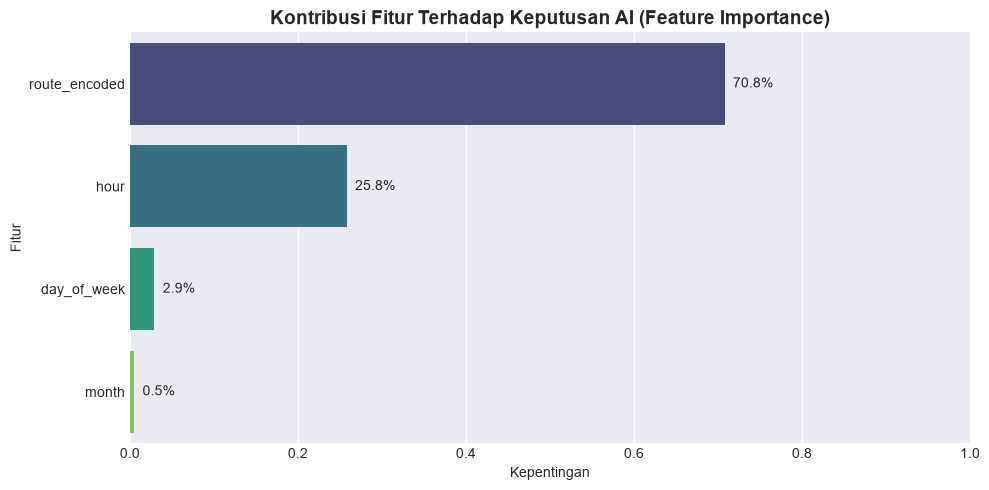

In [2]:
# Menerapkan Log-Transform
y_train_log = np.log1p(y_train)

# Hyperparameter Teroptimasi
best_params = {
    'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5, 
    'min_samples_leaf': 4, 'random_state': 42, 'n_jobs': -1
}

print("Melatih Model Random Forest...")
rf_model = RandomForestRegressor(**best_params)
rf_model.fit(X_train, y_train_log)

# Plot Feature Importance
feature_df = pd.DataFrame({
    'Fitur': features, 'Kepentingan': rf_model.feature_importances_
}).sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Kontribusi Fitur Terhadap Keputusan AI (Feature Importance)', fontsize=14, fontweight='bold')
for index, value in enumerate(feature_df['Kepentingan']):
    plt.text(value + 0.01, index, f"{value*100:.1f}%", va='center')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 2. Bedah Kinerja Model (Peak vs Off-Peak)
Mengevaluasi akurasi prediksi setelah metrik dikembalikan dari skala logaritmik, dengan memecah *error* ke dalam klaster kepadatan untuk membuktikan kelayakan performa AI saat kondisi operasional sedang sibuk (*Peak Hour*).

In [8]:
# Prediksi & Reverse Log
preds_log = rf_model.predict(X_test)
preds_rounded = np.round(np.expm1(preds_log)).astype(int)
y_test_arr = np.array(y_test)

# Evaluasi Peak Hour (> 50 Penumpang)
mask_peak = y_test_arr > 50
mape_peak = mean_absolute_percentage_error(y_test_arr[mask_peak], preds_rounded[mask_peak]) * 100
wmape_peak = (mean_absolute_error(y_test_arr[mask_peak], preds_rounded[mask_peak]) / y_test_arr[mask_peak].mean()) * 100

print(f"=== KINERJA AI PADA JAM SIBUK (KONDISI KRUSIAL) ===")
print(f"Total Data Uji     : {mask_peak.sum():,} jam operasional")
print(f"MAPE (Peak Hour)   : {mape_peak:.2f}%")
print(f"WMAPE (Peak Hour)  : {wmape_peak:.2f}%")

=== KINERJA AI PADA JAM SIBUK (KONDISI KRUSIAL) ===
Total Data Uji     : 340,149 jam operasional
MAPE (Peak Hour)   : 18.53%
WMAPE (Peak Hour)  : 15.50%
